In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import PcmPy as pcm
import globals as gl
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
plt.style.use('default')

In [22]:
experiment = 'smp3'
sn = 100
pinfo = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')
channels_emg = pinfo[pinfo.sn == sn].reset_index().channels_emg[0].split(',')
scaler = MinMaxScaler()

In [23]:
mep_amp = pd.read_csv(os.path.join(gl.baseDir, experiment, 'emg',
                                       f'subj{sn}', 'mep_amp.tsv'), sep='\t')
# mep_amp[channels_emg] = scaler.fit_transform(mep_amp[channels_emg])
mep_amp[[ch + '_bs' for ch in channels_emg]] = scaler.fit_transform(mep_amp[[ch + '_bs' for ch in channels_emg]])
norm = np.linalg.norm(mep_amp[channels_emg].to_numpy(), axis=-1)
norm_bs = np.linalg.norm(mep_amp[[ch + '_bs' for ch in channels_emg]].to_numpy(), axis=-1)
mep_amp['norm'] = norm
mep_amp['norm_bs'] = norm_bs

plt.show()

<Axes: xlabel='epoch', ylabel='norm_bs'>

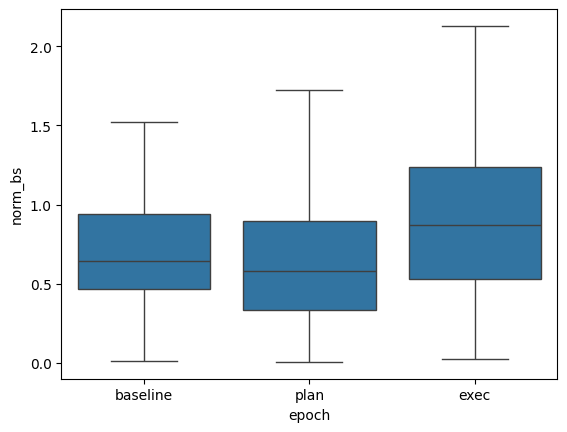

In [24]:
sb.boxplot(data=mep_amp, y='norm_bs', x='epoch', order=['baseline', 'plan', 'exec'], showfliers=False)

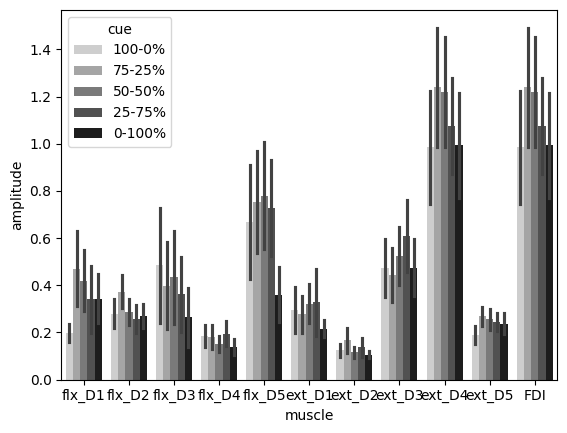

In [25]:
# planning
plan = mep_amp[mep_amp['epoch']=='plan']
plan_melt = pd.melt(plan, id_vars=['cue'], value_vars=channels_emg, var_name='muscle', value_name='amplitude')
sb.barplot(data=plan_melt, x='muscle', hue='cue', y='amplitude', palette=list(gl.colour_mapping.values())[:5], hue_order=list(gl.colour_mapping.keys())[:5], errorbar='se')
plt.show()

<Axes: xlabel='epoch', ylabel='norm'>

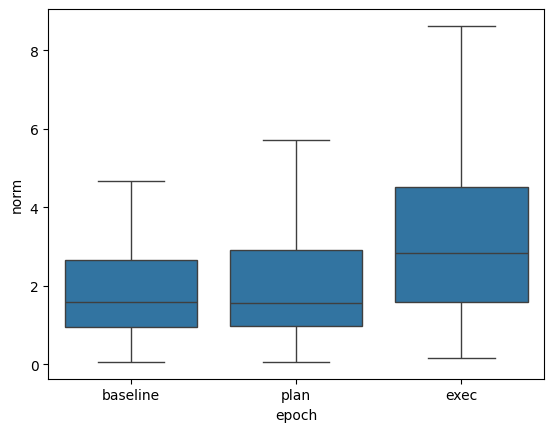

In [26]:
sb.boxplot(data=mep_amp, y='norm', x='epoch', order=['baseline', 'plan', 'exec'], showfliers=False)

<Axes: xlabel='cue', ylabel='norm'>

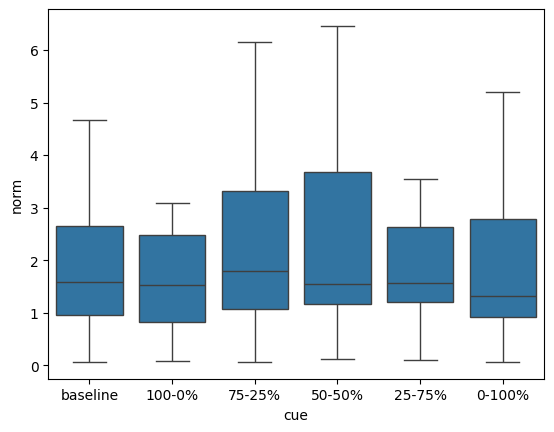

In [27]:
plan_bs = mep_amp[(mep_amp['epoch']=='plan') | (mep_amp['epoch']=='baseline')]
plan_bs.loc[plan_bs['epoch']=='baseline', 'cue'] = 'baseline'
sb.boxplot(data=plan_bs, y='norm', x='cue', order=['baseline'] + list(gl.colour_mapping.keys())[:5], showfliers=False)

<Axes: >

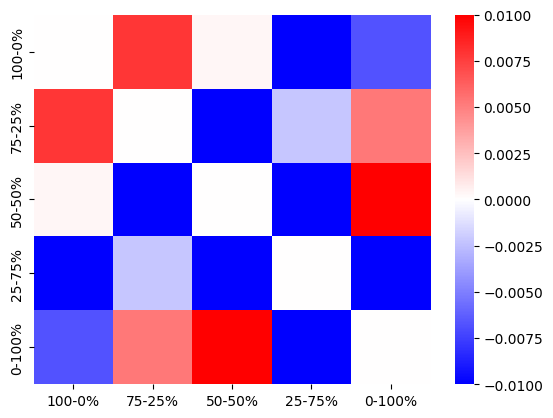

In [28]:
plan_avg_run = plan.groupby(['cue', 'BN']).mean(numeric_only=True).reset_index()
cond_vec = plan_avg_run['cue'].map(gl.regressor_mapping)
obs_des = {'cond_vec': cond_vec,
           'part_vec': plan_avg_run['BN']}

meas = plan_avg_run[channels_emg].to_numpy()

Y = pcm.dataset.Dataset(meas, obs_descriptors=obs_des)

G, _ = pcm.est_G_crossval(Y.measurements,
                       Y.obs_descriptors['cond_vec'],
                       Y.obs_descriptors['part_vec'],
                       X=pcm.indicator(Y.obs_descriptors['part_vec']),)
D = pcm.G_to_dist(G)

sb.heatmap(D,
           vmin=-0.01,
           vmax=.01,
           cbar=True,
           cmap='bwr',
           xticklabels=list(gl.regressor_mapping.keys())[:5],
           yticklabels=list(gl.regressor_mapping.keys())[:5],)

<Axes: >

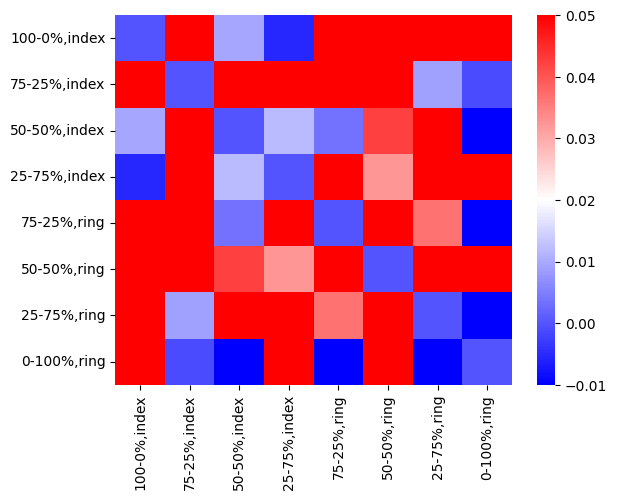

In [30]:
exec = mep_amp[mep_amp['epoch']=='exec']
exec_avg_run = exec.groupby(['cue', 'BN', 'stimFinger']).mean(numeric_only=True).reset_index()
cond_vec = exec_avg_run['cue'].astype(str) + ',' + exec_avg_run['stimFinger'].astype(str)
obs_des = {'cond_vec': cond_vec,
           'part_vec': exec_avg_run['BN']}

meas = exec_avg_run[channels_emg].to_numpy()

Y = pcm.dataset.Dataset(meas, obs_descriptors=obs_des)

G, _ = pcm.est_G_crossval(Y.measurements,
                       Y.obs_descriptors['cond_vec'],
                       Y.obs_descriptors['part_vec'],
                       X=pcm.indicator(Y.obs_descriptors['part_vec']),)
D = pcm.G_to_dist(G)

sb.heatmap(D,
           vmin=-0.01,
           vmax=.05,
           cbar=True,
           cmap='bwr',
           xticklabels=list(gl.regressor_mapping.keys())[5:13],
           yticklabels=list(gl.regressor_mapping.keys())[5:13],)